In [1]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 7.2 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   ---------------------------------------- 5/5 [yfinance]



In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

plt.style.use('seaborn-v0_8')

In [6]:
def get_cbar_rates(start_date, end_date):
    dates = pd.date_range(start=start_date, end=end_date, freq='MS')
    records = []
    
    for date in dates:
        url = f"https://www.cbar.az/currencies/{date.strftime('%d.%m.%Y')}.xml"
        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                import xml.etree.ElementTree as ET
                root = ET.fromstring(response.content)
                for valute in root.findall('.//Valute'):
                    if valute.get('Code') == 'USD':
                        rate = float(valute.find('Value').text)
                        records.append({'date': date, 'AZN_USD': rate})
        except:
            continue
    
    return pd.DataFrame(records)

# Start from 2014 to capture the 2015 devaluation
azn_df = get_cbar_rates('2014-01-01', '2024-01-01')
print(azn_df.shape)
print(azn_df.head(10))

(121, 2)
        date  AZN_USD
0 2014-01-01   0.7845
1 2014-02-01   0.7842
2 2014-03-01   0.7844
3 2014-04-01   0.7843
4 2014-05-01   0.7843
5 2014-06-01   0.7844
6 2014-07-01   0.7844
7 2014-08-01   0.7843
8 2014-09-01   0.7844
9 2014-10-01   0.7844


In [9]:
# Prepare Brent data
brent_monthly = brent['Close'].resample('MS').mean()
brent_df = brent_monthly.reset_index()
brent_df.columns = ['date', 'brent_price']

# Merge with AZN data
df = azn_df.merge(brent_df, on='date', how='inner')
df = df.sort_values('date').reset_index(drop=True)

print(df.shape)
print(df.head())

(60, 3)
        date  AZN_USD  brent_price
0 2019-01-01      1.7    60.121905
1 2019-02-01      1.7    64.276315
2 2019-03-01      1.7    67.027619
3 2019-04-01      1.7    71.628572
4 2019-05-01      1.7    70.311818


In [10]:
# Since AZN is pegged, we analyze oil price trends and volatility instead
df['oil_change'] = df['brent_price'].pct_change() * 100
df['oil_volatility'] = df['oil_change'].rolling(6).std()
df['oil_ma3'] = df['brent_price'].rolling(3).mean()
df['oil_ma12'] = df['brent_price'].rolling(12).mean()

# Classify oil price regime
df['oil_regime'] = pd.cut(df['brent_price'], 
                           bins=[0, 40, 70, 90, 200],
                           labels=['Very Low (<$40)', 'Low ($40-70)', 
                                  'Medium ($70-90)', 'High (>$90)'])

print(df[['date', 'brent_price', 'oil_change', 'oil_volatility', 'oil_regime']].tail(10))

         date  brent_price  oil_change  oil_volatility       oil_regime
50 2023-03-01    79.206956   -5.152130        5.416806  Medium ($70-90)
51 2023-04-01    83.368948    5.254578        5.786905  Medium ($70-90)
52 2023-05-01    75.632274   -9.280043        6.569618  Medium ($70-90)
53 2023-06-01    74.925714   -0.934204        5.326647  Medium ($70-90)
54 2023-07-01    80.355500    7.246893        6.197379  Medium ($70-90)
55 2023-08-01    85.104348    5.909798        6.738619  Medium ($70-90)
56 2023-09-01    92.766499    9.003244        6.838069      High (>$90)
57 2023-10-01    88.704091   -4.379176        7.281877  Medium ($70-90)
58 2023-11-01    82.027727   -7.526557        6.792989  Medium ($70-90)
59 2023-12-01    77.324000   -5.734314        7.400071  Medium ($70-90)


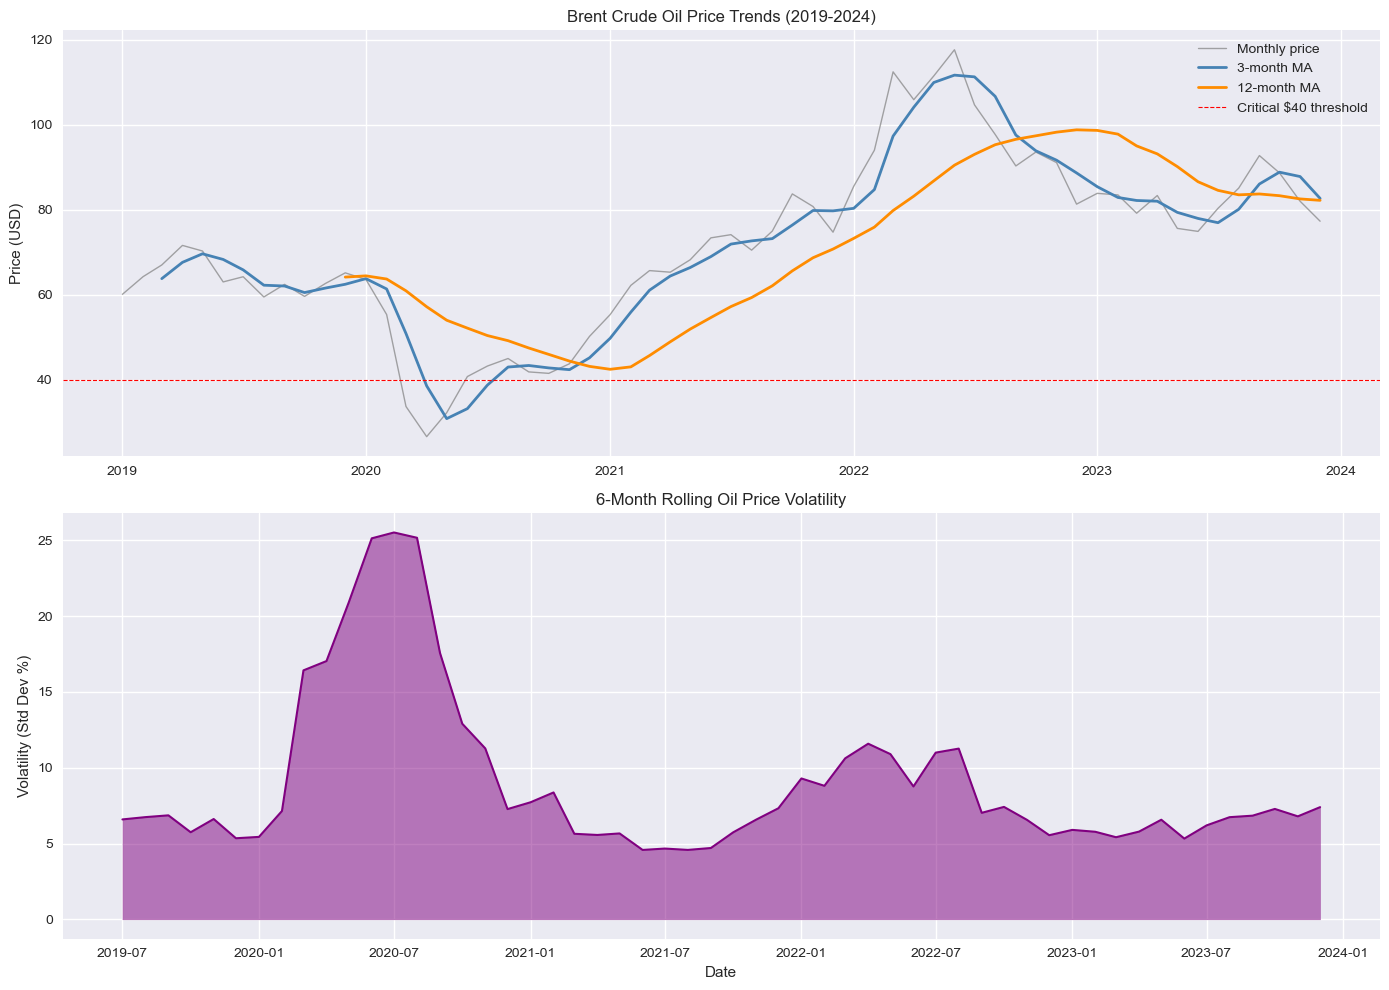

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Brent price with moving averages
axes[0].plot(df['date'], df['brent_price'], color='gray', linewidth=1, alpha=0.7, label='Monthly price')
axes[0].plot(df['date'], df['oil_ma3'], color='steelblue', linewidth=2, label='3-month MA')
axes[0].plot(df['date'], df['oil_ma12'], color='darkorange', linewidth=2, label='12-month MA')
axes[0].axhline(y=40, color='red', linestyle='--', linewidth=0.8, label='Critical $40 threshold')
axes[0].set_title('Brent Crude Oil Price Trends (2019-2024)')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Plot 2: Oil price volatility
axes[1].fill_between(df['date'], df['oil_volatility'], alpha=0.5, color='purple')
axes[1].plot(df['date'], df['oil_volatility'], color='purple', linewidth=1.5)
axes[1].set_title('6-Month Rolling Oil Price Volatility')
axes[1].set_ylabel('Volatility (Std Dev %)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('oil_analysis.png', dpi=150)
plt.show()

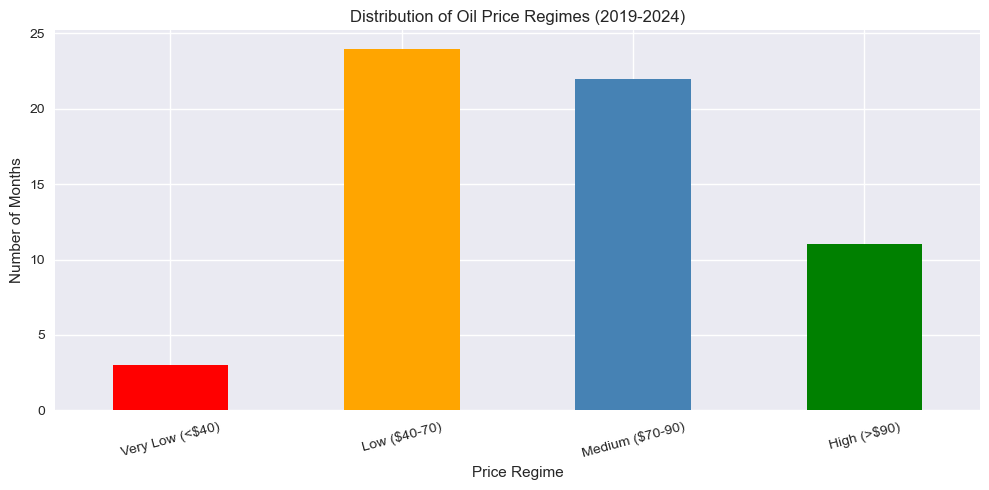

oil_regime
Very Low (<$40)     3
Low ($40-70)       24
Medium ($70-90)    22
High (>$90)        11
Name: count, dtype: int64


In [12]:
# Oil regime distribution - how many months in each price regime
regime_counts = df['oil_regime'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
colors = ['red', 'orange', 'steelblue', 'green']
regime_counts.plot(kind='bar', color=colors)
plt.title('Distribution of Oil Price Regimes (2019-2024)')
plt.xlabel('Price Regime')
plt.ylabel('Number of Months')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('oil_regimes.png', dpi=150)
plt.show()

print(regime_counts)

                            OLS Regression Results                            
Dep. Variable:            brent_price   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     39.04
Date:                Tue, 12 May 2026   Prob (F-statistic):           5.29e-08
Time:                        21:56:18   Log-Likelihood:                -249.87
No. Observations:                  60   AIC:                             503.7
Df Residuals:                      58   BIC:                             507.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.0700      4.039     12.397      0.0

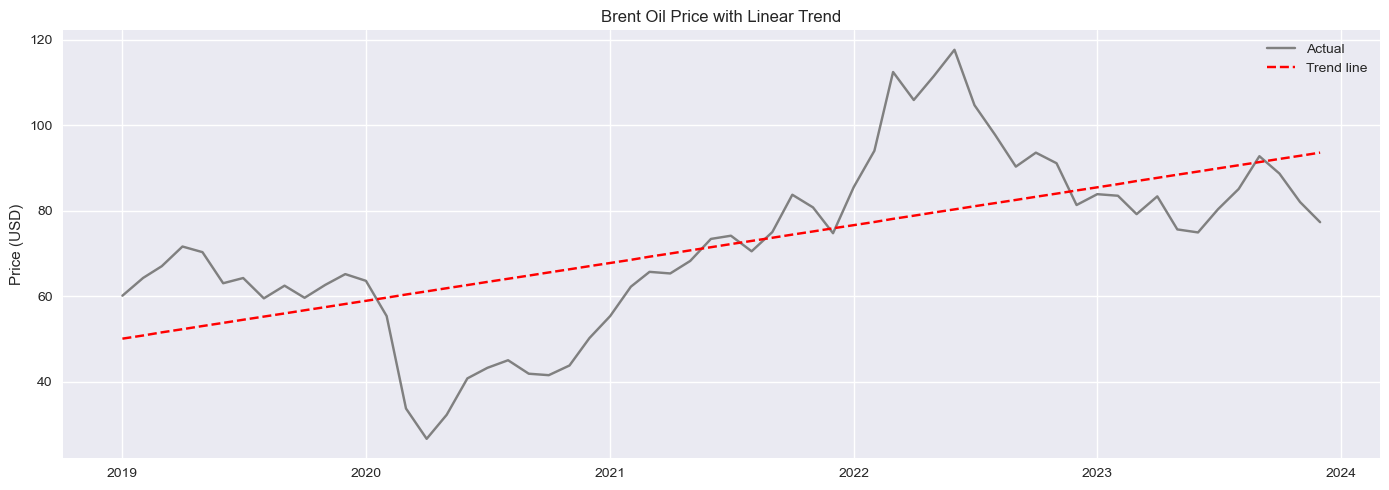

In [13]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

df_clean = df.dropna(subset=['brent_price'])
df_clean['time_index'] = range(len(df_clean))

X = add_constant(df_clean['time_index'])
y = df_clean['brent_price']

model = OLS(y, X).fit()
print(model.summary())

df_clean['predicted'] = model.predict(X)

plt.figure(figsize=(14, 5))
plt.plot(df_clean['date'], df_clean['brent_price'], color='gray', label='Actual')
plt.plot(df_clean['date'], df_clean['predicted'], color='red', linestyle='--', label='Trend line')
plt.title('Brent Oil Price with Linear Trend')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('oil_trend.png', dpi=150)
plt.show()

In [14]:
df.to_csv('C:/Users/alekb/Desktop/Portfolio/Project 02/azn_oil_analysis.csv', index=False)
print("Exported successfully")
print(f"\nKey stats:")
print(f"Average Brent price: ${df['brent_price'].mean():.2f}")
print(f"Max Brent price: ${df['brent_price'].max():.2f}")
print(f"Min Brent price: ${df['brent_price'].min():.2f}")
print(f"Highest volatility month: {df.loc[df['oil_volatility'].idxmax(), 'date'].strftime('%B %Y')}")

Exported successfully

Key stats:
Average Brent price: $71.83
Max Brent price: $117.66
Min Brent price: $26.63
Highest volatility month: July 2020
